# Multi-topic MATH: GRPO and correct-to-wrong constraint
Run prepare_math_data.py, train.py, evaluate.py, compare.py first. The original plots use the full held-out test. Additional plots at the end use only questions that were **not capped for any method**. The same questions are compared across methods, and the number retained is shown. This selected subset is diagnostic, not a replacement for full-test accuracy.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd()
if not (root / 'configs' / 'general_math_baseline.json').exists():
    root = root / 'pact_grpo_math'
config_name = 'general_math_baseline.json'
config = json.loads((root / 'configs' / config_name).read_text(encoding='utf-8'))
output = root / 'outputs' / config['run_name']
results = pd.read_csv(output / 'comparison.csv')
display(results)
methods = ['initial', 'grpo', 'grpo_reference_kl', 'cokl_grpo', 'flip_constrained_grpo']
labels = ['Initial', 'GRPO', 'GRPO + KL', 'CoKL-GRPO', 'Flip constraint']
filtered_rows = []
cohort_rows = []
for seed in config['training_seeds']:
    predictions = {}
    for method in methods:
        path = output / f'seed_{seed}' / method / 'evaluation.json'
        if not path.exists():
            raise FileNotFoundError(f'Missing {path}; finish evaluate.py for every method first')
        evaluation = json.loads(path.read_text(encoding='utf-8'))
        predictions[method] = {item['uid']: item for item in evaluation['test']['predictions']}
    ids = set(predictions['initial'])
    if any(set(predictions[m]) != ids for m in methods):
        raise ValueError(f'Seed {seed}: test question IDs differ across methods')
    shared = {uid for uid in ids if all(not predictions[m][uid]['capped'] for m in methods)}
    if not shared:
        print(f'Seed {seed}: no shared uncapped test questions; full-test plots remain valid')
    before = predictions['initial']
    cohort_rows.append({'seed': seed, 'full_test_n': len(ids), 'shared_uncapped_n': len(shared),
                        'excluded_n': len(ids) - len(shared),
                        'initially_correct_shared_n': sum(before[uid]['correct'] for uid in shared)})
    for method in methods:
        after = predictions[method]
        row = {'seed': seed, 'method': method, 'shared_n': len(shared),
               'accuracy': (np.mean([after[uid]['correct'] for uid in shared]) if shared else np.nan),
               'correct_to_wrong': sum(before[uid]['correct'] and not after[uid]['correct'] for uid in shared),
               'wrong_to_correct': sum(not before[uid]['correct'] and after[uid]['correct'] for uid in shared)}
        topic_accuracies = []
        for topic in config['topics']:
            topic_ids = [uid for uid in shared if before[uid]['topic'] == topic]
            originally_correct = sum(before[uid]['correct'] for uid in topic_ids)
            row[f'n_{topic}'] = len(topic_ids)
            row[f'initially_correct_{topic}'] = originally_correct
            row[f'accuracy_{topic}'] = (np.mean([after[uid]['correct'] for uid in topic_ids])
                                         if topic_ids else np.nan)
            row[f'flip_rate_{topic}'] = (sum(before[uid]['correct'] and not after[uid]['correct']
                                            for uid in topic_ids) / originally_correct
                                        if originally_correct else np.nan)
            topic_accuracies.append(row[f'accuracy_{topic}'])
        row['worst_topic_accuracy'] = (np.nanmin(topic_accuracies) if shared else np.nan)
        filtered_rows.append(row)
filtered = pd.DataFrame(filtered_rows)
cohorts = pd.DataFrame(cohort_rows)
display(cohorts)
display(filtered[['seed', 'method', 'shared_n', 'accuracy', 'correct_to_wrong', 'wrong_to_correct']])

,seed,method,test_macro_accuracy,test_worst_topic_accuracy,validation_macro_accuracy,test_capped_rate,test_no_box_rate,validation_capped_rate,correct_to_wrong,initially_correct_test,...,test_flip_rate_geometry,initially_correct_test_geometry,test_number_theory,validation_number_theory,test_flip_rate_number_theory,initially_correct_test_number_theory,test_counting_and_probability,validation_counting_and_probability,test_flip_rate_counting_and_probability,initially_correct_test_counting_and_probability
0,42,initial,0.29375,0.150,0.3250,0.02500,0.06875,0.0375,0,47,...,0.000000,12,0.150,0.30,0.000000,6,0.225,0.35,0.000000,9
1,42,grpo,0.30625,0.200,0.3000,0.01250,0.04375,0.0375,10,47,...,0.333333,12,0.200,0.35,0.333333,6,0.250,0.30,0.222222,9
2,42,grpo_reference_kl,0.26875,0.125,0.3125,0.00625,0.04375,0.0125,11,47,...,0.416667,12,0.125,0.40,0.333333,6,0.300,0.30,0.111111,9
3,42,cokl_grpo,0.28125,0.150,0.3125,0.01875,0.04375,0.0625,10,47,...,0.333333,12,0.150,0.20,0.333333,6,0.225,0.30,0.111111,9
4,42,flip_constrained_grpo,0.31250,0.200,0.3000,0.01250,0.05000,0.0625,7,47,...,0.333333,12,0.200,0.30,0.166667,6,0.250,0.35,0.111111,9


,seed,full_test_n,shared_uncapped_n,excluded_n,initially_correct_shared_n
0,42,160,151,9,46


,seed,method,shared_n,accuracy,correct_to_wrong,wrong_to_correct
0,42,initial,151,0.304636,0,0
1,42,grpo,151,0.311258,9,10
2,42,grpo_reference_kl,151,0.284768,10,7
3,42,cokl_grpo,151,0.298013,9,8
4,42,flip_constrained_grpo,151,0.331126,6,10


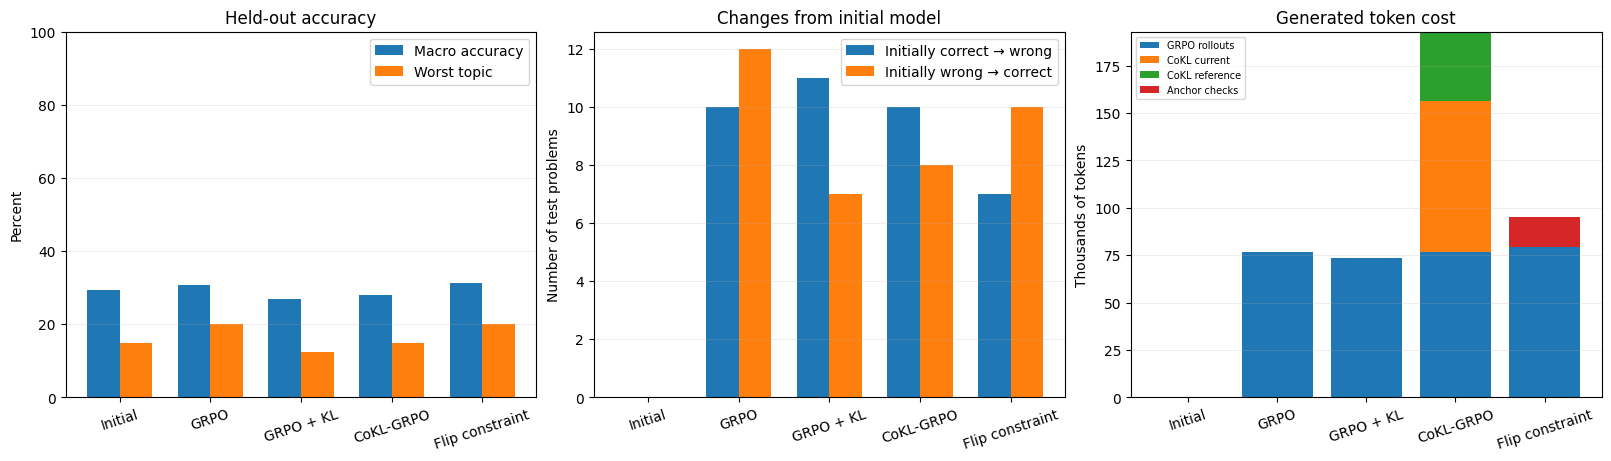

In [2]:
methods = ['initial', 'grpo', 'grpo_reference_kl', 'cokl_grpo', 'flip_constrained_grpo']
labels = ['Initial', 'GRPO', 'GRPO + KL', 'CoKL-GRPO', 'Flip constraint']
means = results.groupby('method').mean(numeric_only=True).reindex(methods)
x = np.arange(len(methods))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].bar(x-.18, means.test_macro_accuracy*100, .36, label='Macro accuracy')
axes[0].bar(x+.18, means.test_worst_topic_accuracy*100, .36, label='Worst topic')
axes[0].set(title='Held-out accuracy', ylabel='Percent', ylim=(0,100))
axes[0].legend()
axes[1].bar(x-.18, means.correct_to_wrong, .36, label='Initially correct → wrong')
axes[1].bar(x+.18, means.wrong_to_correct, .36, label='Initially wrong → correct')
axes[1].set(title='Changes from initial model', ylabel='Number of test problems')
axes[1].legend()
axes[2].bar(x, means.rollout_tokens/1000, label='GRPO rollouts')
axes[2].bar(x, means.cokl_generated_tokens/1000, bottom=means.rollout_tokens/1000, label='CoKL current')
axes[2].bar(x, means.cokl_reference_buffer_tokens/1000, bottom=(means.rollout_tokens+means.cokl_generated_tokens)/1000, label='CoKL reference')
axes[2].bar(x, means.retention_eval_tokens/1000, bottom=(means.rollout_tokens+means.cokl_generated_tokens+means.cokl_reference_buffer_tokens)/1000, label='Anchor checks')
axes[2].set(title='Generated token cost', ylabel='Thousands of tokens')
axes[2].legend(fontsize=7)
for ax in axes:
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis='y', alpha=.2)
plt.show()

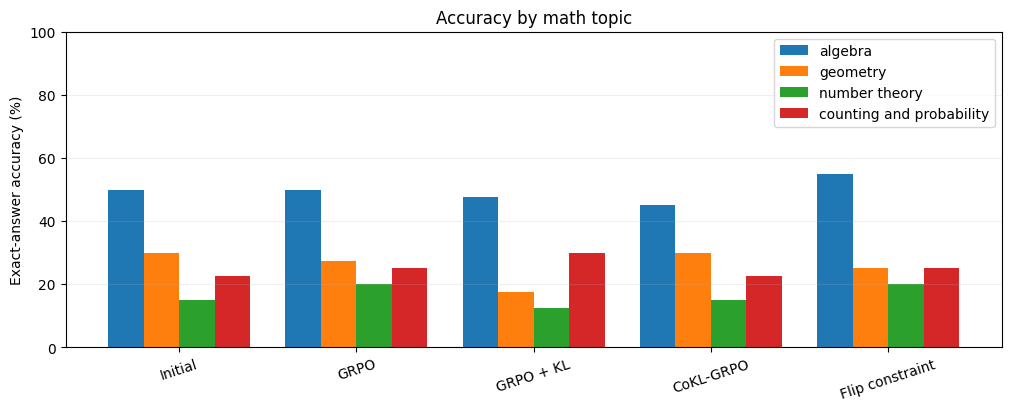

,rollout_tokens,cokl_generated_tokens,cokl_reference_buffer_tokens,retention_eval_tokens,train_seconds,mixed_group_rate,retention_checks,retention_flip_rate_train,retention_active_updates
method,,,,,,,,,
initial,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.000,0.0
grpo,76852.0,0.0,0.0,0.0,4482.987,0.453,0.0,0.000,0.0
grpo_reference_kl,73688.0,0.0,0.0,0.0,4898.076,0.375,0.0,0.000,0.0
cokl_grpo,76497.0,80017.0,36453.0,0.0,26038.209,0.422,0.0,0.000,0.0
flip_constrained_grpo,79425.0,0.0,0.0,15746.0,8719.566,0.422,64.0,0.375,64.0


In [3]:
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
width = .8 / len(config['topics'])
for i, topic in enumerate(config['topics']):
    ax.bar(x-.4+(i+.5)*width, means[f'test_{topic}']*100, width, label=topic.replace('_',' '))
ax.set(title='Accuracy by math topic', ylabel='Exact-answer accuracy (%)', ylim=(0,100))
ax.set_xticks(x, labels, rotation=18)
ax.legend()
ax.grid(axis='y', alpha=.2)
plt.show()
display(means[['rollout_tokens','cokl_generated_tokens','cokl_reference_buffer_tokens','retention_eval_tokens','train_seconds','mixed_group_rate','retention_checks','retention_flip_rate_train','retention_active_updates']].round(3))

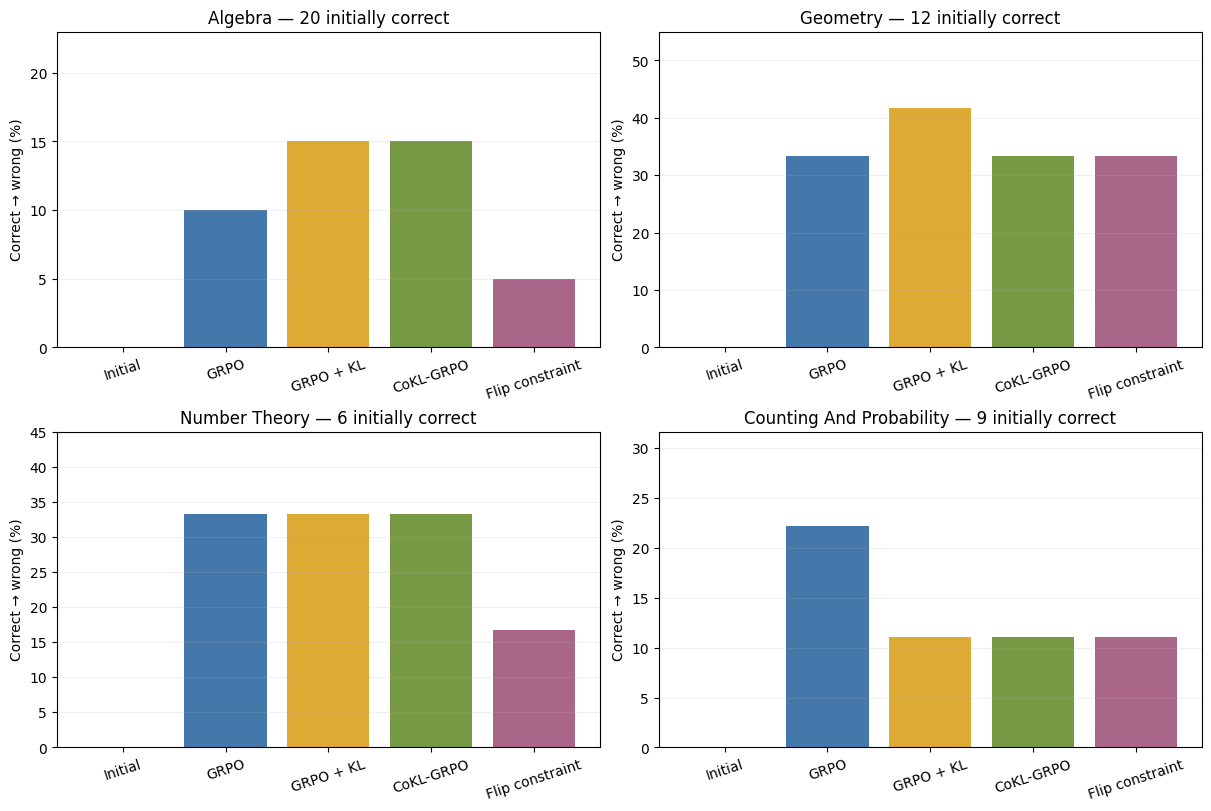

,initially_correct,initial,grpo,grpo_reference_kl,cokl_grpo,flip_constrained_grpo
topic,,,,,,
algebra,20.0,0.0,0.100,0.150,0.150,0.050
geometry,12.0,0.0,0.333,0.417,0.333,0.333
number_theory,6.0,0.0,0.333,0.333,0.333,0.167
counting_and_probability,9.0,0.0,0.222,0.111,0.111,0.111


In [4]:
# Held-out correct-to-wrong rate is conditional on the initial model being correct.
# Each panel shows its denominator so small-topic percentages are not mistaken for strong evidence.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
flip_rows = []
for ax, topic in zip(axes.flat, config['topics']):
    original_correct = means.loc['initial', f'initially_correct_test_{topic}']
    rates = means[f'test_flip_rate_{topic}'] * 100
    if original_correct > 0:
        ax.bar(x, rates, color=['#8090a6', '#4477aa', '#ddaa33', '#779944', '#aa6688'])
        ax.set_ylim(0, max(10, min(100, rates.max() * 1.2 + 5)))
    else:
        ax.text(.5, .5, 'No initially correct test cases', ha='center', va='center', transform=ax.transAxes)
        ax.set_ylim(0, 100)
    ax.set(title=f"{topic.replace('_', ' ').title()} — {int(original_correct)} initially correct", ylabel='Correct → wrong (%)')
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis='y', alpha=.2)
    flip_rows.append({'topic': topic, 'initially_correct': original_correct, **{m: (means.loc[m, f'test_flip_rate_{topic}'] if original_correct else np.nan) for m in methods}})
plt.show()
display(pd.DataFrame(flip_rows).set_index('topic').round(3))

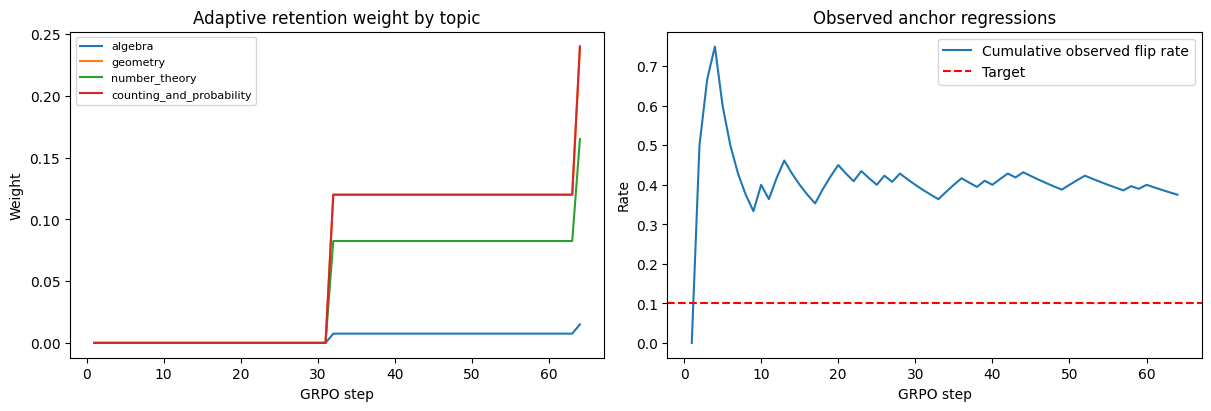

In [5]:
folder = output / f"seed_{config['training_seeds'][0]}" / 'flip_constrained_grpo'
metrics = pd.read_json(folder / 'train_metrics.jsonl', lines=True)
topics = config['topics']
fig, axes = plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for topic in topics:
    axes[0].plot(metrics.step, metrics.retention_multipliers.map(lambda d: d[topic]), label=topic)
axes[0].set(title='Adaptive retention weight by topic', xlabel='GRPO step', ylabel='Weight')
axes[0].legend(fontsize=8)
axes[1].plot(metrics.step, metrics.retention_flips / metrics.retention_checks.replace(0,np.nan), label='Cumulative observed flip rate')
axes[1].axhline(config['target_flip_rate'],color='red',linestyle='--',label='Target')
axes[1].set(title='Observed anchor regressions',xlabel='GRPO step',ylabel='Rate')
axes[1].legend()
plt.show()

## Diagnostic: questions completed by every method
A test question is included below only when **initial and all four trained methods are uncapped**. This keeps the question set identical across methods. Excluding questions based on the models' outputs introduces selection bias, so use these charts to diagnose truncation, not as the main performance claim.

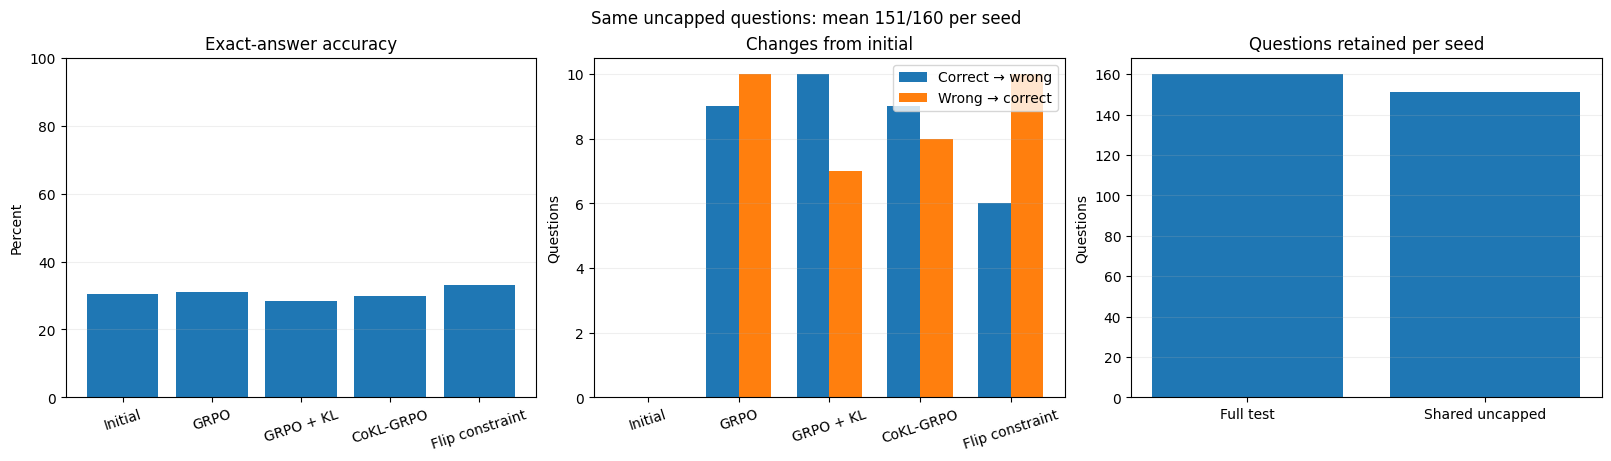

,seed,method,shared_n,accuracy,correct_to_wrong,wrong_to_correct
0,42,initial,151,0.305,0,0
1,42,grpo,151,0.311,9,10
2,42,grpo_reference_kl,151,0.285,10,7
3,42,cokl_grpo,151,0.298,9,8
4,42,flip_constrained_grpo,151,0.331,6,10


In [6]:
filtered_means = filtered.groupby('method').mean(numeric_only=True).reindex(methods)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
axes[0].bar(x, filtered_means.accuracy * 100)
axes[0].set(title='Exact-answer accuracy', ylabel='Percent', ylim=(0, 100))
axes[1].bar(x-.18, filtered_means.correct_to_wrong, .36, label='Correct → wrong')
axes[1].bar(x+.18, filtered_means.wrong_to_correct, .36, label='Wrong → correct')
axes[1].set(title='Changes from initial', ylabel='Questions')
axes[1].legend()
axes[2].bar(['Full test', 'Shared uncapped'],
            [cohorts.full_test_n.mean(), cohorts.shared_uncapped_n.mean()])
axes[2].set(title='Questions retained per seed', ylabel='Questions')
for ax in axes[:2]:
    ax.set_xticks(x, labels, rotation=18)
for ax in axes:
    ax.grid(axis='y', alpha=.2)
fig.suptitle(f"Same uncapped questions: mean {cohorts.shared_uncapped_n.mean():.0f}/{cohorts.full_test_n.mean():.0f} per seed")
plt.show()
display(filtered[['seed', 'method', 'shared_n', 'accuracy', 'correct_to_wrong', 'wrong_to_correct']].round(3))

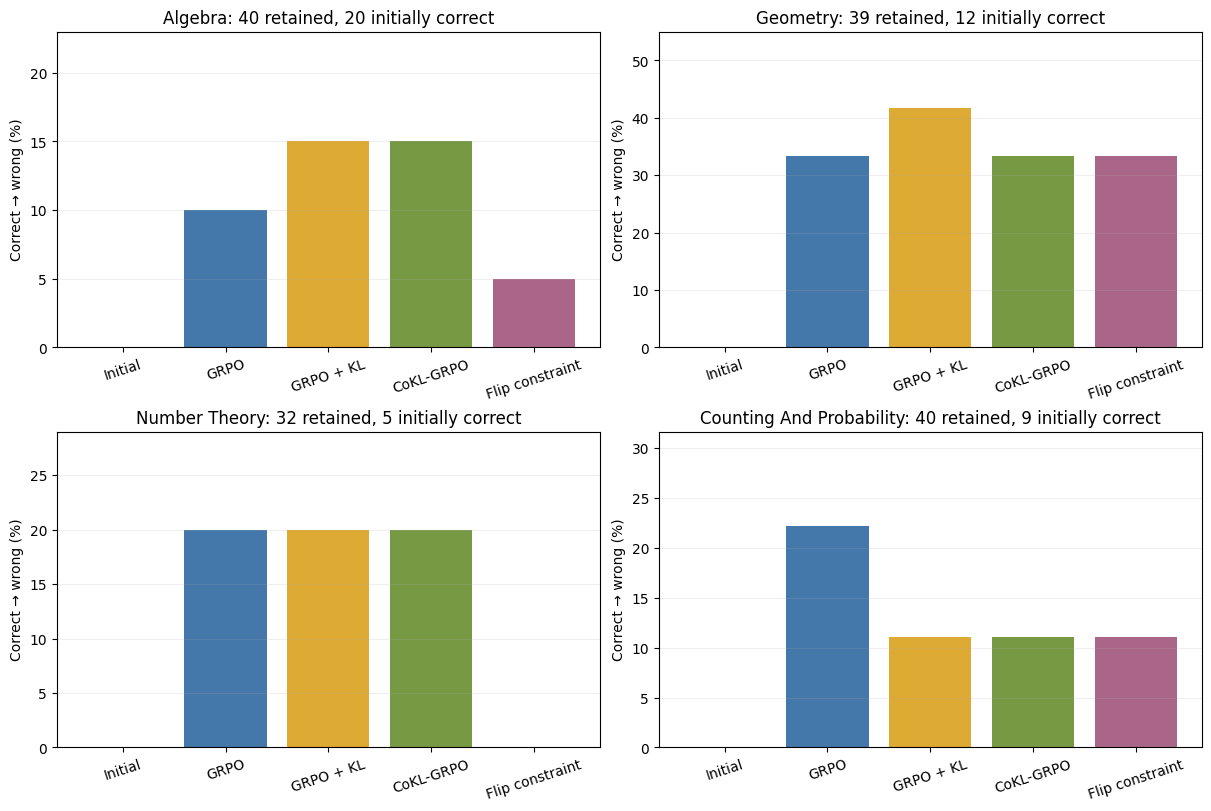

,retained_n,initially_correct_n,initial,grpo,grpo_reference_kl,cokl_grpo,flip_constrained_grpo
topic,,,,,,,
algebra,40.0,20.0,0.0,0.100,0.150,0.150,0.050
geometry,39.0,12.0,0.0,0.333,0.417,0.333,0.333
number_theory,32.0,5.0,0.0,0.200,0.200,0.200,0.000
counting_and_probability,40.0,9.0,0.0,0.222,0.111,0.111,0.111


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
uncapped_topic_rows = []
for ax, topic in zip(axes.flat, config['topics']):
    n = filtered_means.loc['initial', f'n_{topic}']
    initially_correct = filtered_means.loc['initial', f'initially_correct_{topic}']
    rates = filtered_means[f'flip_rate_{topic}'] * 100
    if initially_correct:
        ax.bar(x, rates.fillna(0), color=['#8090a6', '#4477aa', '#ddaa33', '#779944', '#aa6688'])
        ax.set_ylim(0, max(10, min(100, rates.max() * 1.2 + 5)))
    else:
        ax.text(.5, .5, 'No initially correct questions', ha='center', va='center', transform=ax.transAxes)
        ax.set_ylim(0, 100)
    ax.set(title=f"{topic.replace('_', ' ').title()}: {n:.0f} retained, {initially_correct:.0f} initially correct",
           ylabel='Correct → wrong (%)')
    ax.set_xticks(x, labels, rotation=18)
    ax.grid(axis='y', alpha=.2)
    uncapped_topic_rows.append({'topic': topic, 'retained_n': n,
                                'initially_correct_n': initially_correct,
                                **{m: filtered_means.loc[m, f'flip_rate_{topic}'] for m in methods}})
plt.show()
display(pd.DataFrame(uncapped_topic_rows).set_index('topic').round(3))